In [1]:
# Import de bibliotecas
import pandas as pd

In [20]:
# criar variável para leitura dos arquivos
ler_jan = pd.read_csv('/content/vendas_janeiro.csv')
ler_fev = pd.read_csv('/content/vendas_fevereiro.csv')
ler_mar = pd.read_csv('/content/vendas_marco.csv')

In [21]:
# transformar em dados
df_jan = pd.DataFrame(ler_jan)
df_fev = pd.DataFrame(ler_fev)
df_mar = pd.DataFrame(ler_mar)



In [23]:
#concat
df_quarter01_2026 = pd.concat([df_jan,df_fev,df_mar],ignore_index=True)

In [25]:
# creating file
df_quarter01_2026.to_csv('quarter01-2026.csv',index=False)
display(df_quarter01_2026)

,Data,Produto,Preço,Qtd,Loja
0,2024-01-14,Microfone Condensador,654,9,Rio de Janeiro
1,2024-01-1,Baixo 4 Cordas,1169,1,Rio de Janeiro
2,2024-01-4,Bateria Acústica,2964,1,Curitiba
3,2024-01-27,Violão Nylon,4352,6,Rio de Janeiro
4,2024-01-12,Baixo 4 Cordas,709,10,São Paulo
...,...,...,...,...,...
160,2024-03-21,Teclado Digital,2654,4,Rio de Janeiro
161,2024-03-14,Amplificador 50W,1170,8,Curitiba
162,2024-03-24,Violão Nylon,3556,10,Belo Horizonte
163,2024-03-28,Bateria Acústica,2742,1,São Paulo


## Relatório de Faturamento Bruto - Q1 2026

Este relatório apresenta uma análise do faturamento bruto do primeiro trimestre de 2026, utilizando os dados de vendas consolidados.

In [26]:
# Calcular o Faturamento Bruto
df_quarter01_2026['Faturamento Bruto'] = df_quarter01_2026['Preço'] * df_quarter01_2026['Qtd']

# Exibir as primeiras linhas com o novo campo
display(df_quarter01_2026.head())

,Data,Produto,Preço,Qtd,Loja,Faturamento Bruto
0,2024-01-14,Microfone Condensador,654,9,Rio de Janeiro,5886
1,2024-01-1,Baixo 4 Cordas,1169,1,Rio de Janeiro,1169
2,2024-01-4,Bateria Acústica,2964,1,Curitiba,2964
3,2024-01-27,Violão Nylon,4352,6,Rio de Janeiro,26112
4,2024-01-12,Baixo 4 Cordas,709,10,São Paulo,7090


### Faturamento Bruto Total por Data

Este gráfico mostra a evolução do faturamento bruto diário ao longo do primeiro trimestre.

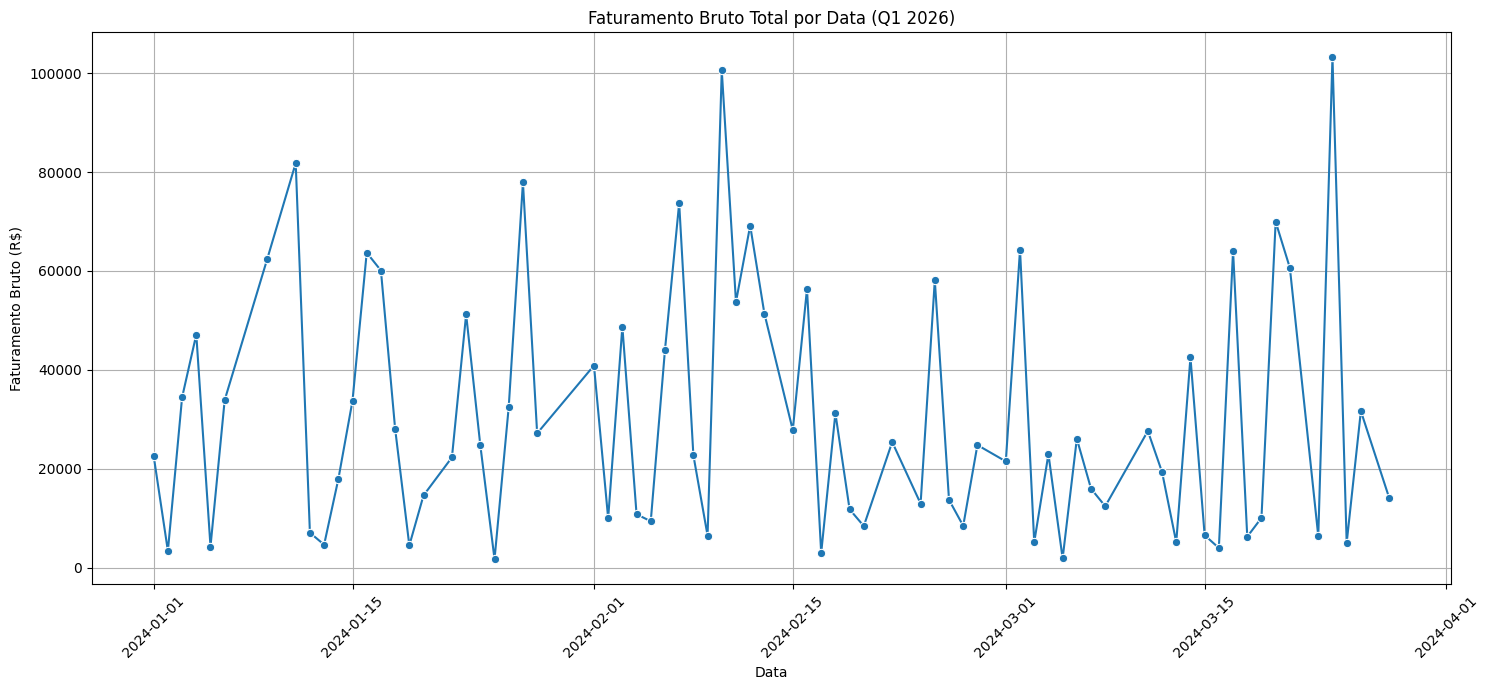

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converter a coluna 'Data' para o tipo datetime, se ainda não estiver
df_quarter01_2026['Data'] = pd.to_datetime(df_quarter01_2026['Data'])

# Agrupar por data e somar o Faturamento Bruto
faturamento_por_data = df_quarter01_2026.groupby('Data')['Faturamento Bruto'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Data', y='Faturamento Bruto', data=faturamento_por_data, marker='o')
plt.title('Faturamento Bruto Total por Data (Q1 2026)')
plt.xlabel('Data')
plt.ylabel('Faturamento Bruto (R$)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Faturamento Bruto por Produto

Este gráfico destaca os produtos que mais contribuíram para o faturamento bruto total.

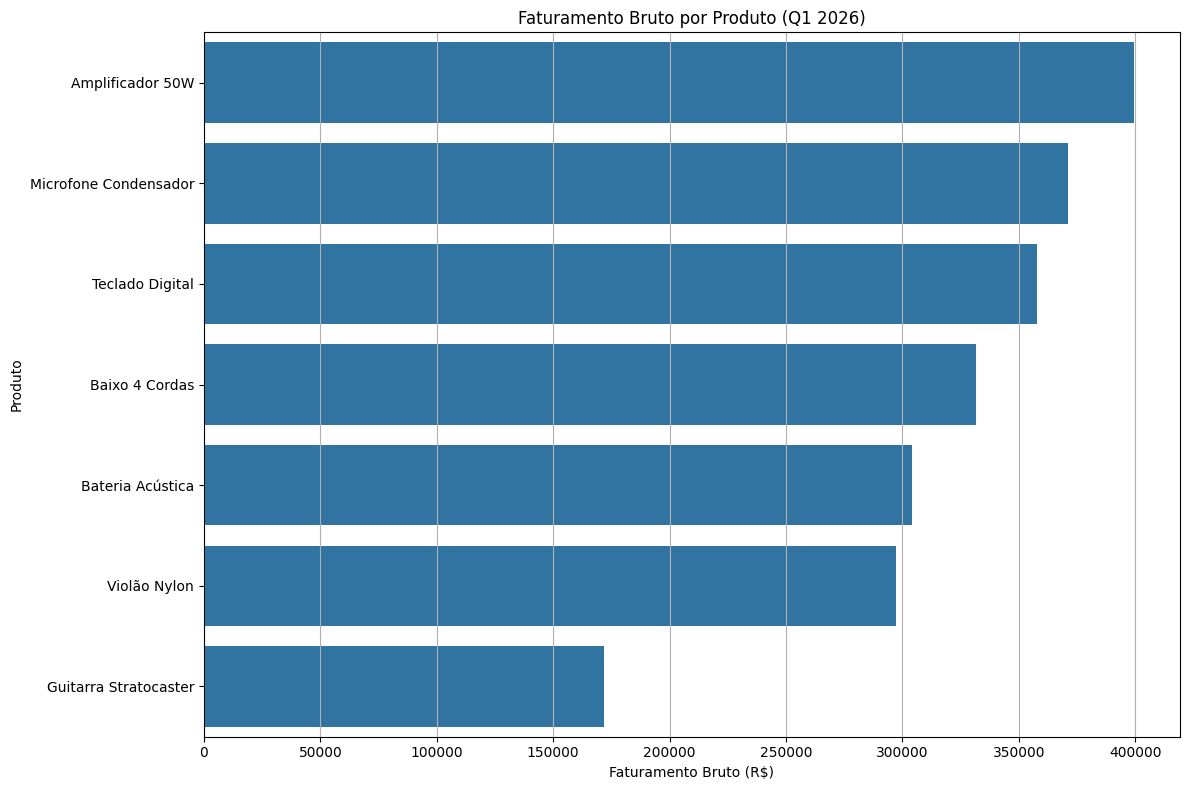

In [28]:
# Agrupar por produto e somar o Faturamento Bruto
faturamento_por_produto = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().reset_index().sort_values(by='Faturamento Bruto', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Faturamento Bruto', y='Produto', data=faturamento_por_produto)
plt.title('Faturamento Bruto por Produto (Q1 2026)')
plt.xlabel('Faturamento Bruto (R$)')
plt.ylabel('Produto')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Faturamento Bruto por Loja

Este gráfico compara o desempenho de faturamento bruto entre as diferentes lojas.

/tmp/ipykernel_11996/378081526.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faturamento Bruto', y='Loja', data=faturamento_por_loja, palette='viridis')


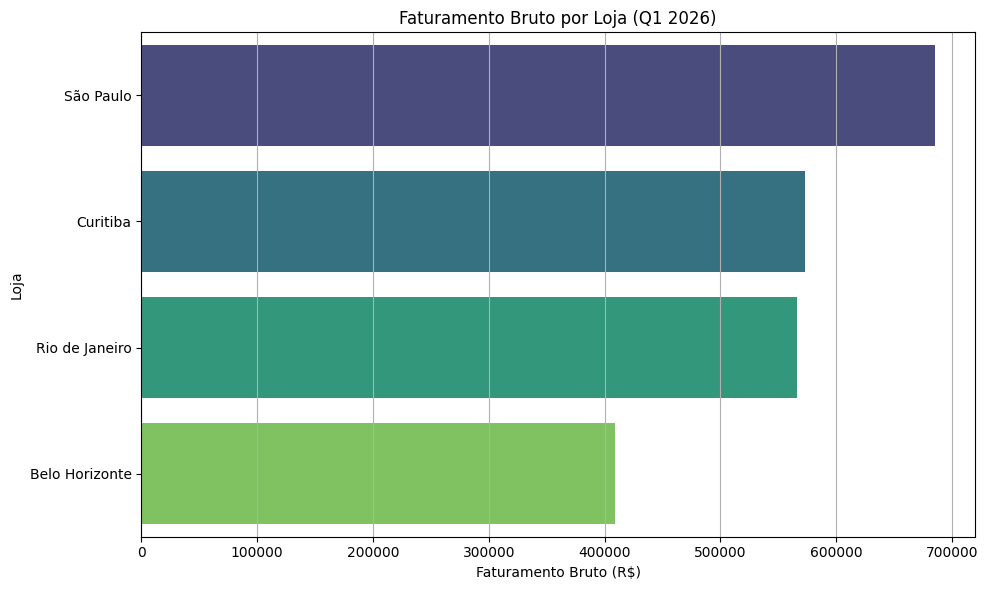

In [29]:
# Agrupar por loja e somar o Faturamento Bruto
faturamento_por_loja = df_quarter01_2026.groupby('Loja')['Faturamento Bruto'].sum().reset_index().sort_values(by='Faturamento Bruto', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Faturamento Bruto', y='Loja', data=faturamento_por_loja, palette='viridis')
plt.title('Faturamento Bruto por Loja (Q1 2026)')
plt.xlabel('Faturamento Bruto (R$)')
plt.ylabel('Loja')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Average Ticket

This section calculates and displays the average ticket per transaction and per store, providing insights into the average sales value.

Overall Average Ticket: R$ 2415.96


/tmp/ipykernel_11996/406398091.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticket Médio', y='Loja', data=ticket_medio_por_loja, palette='magma')


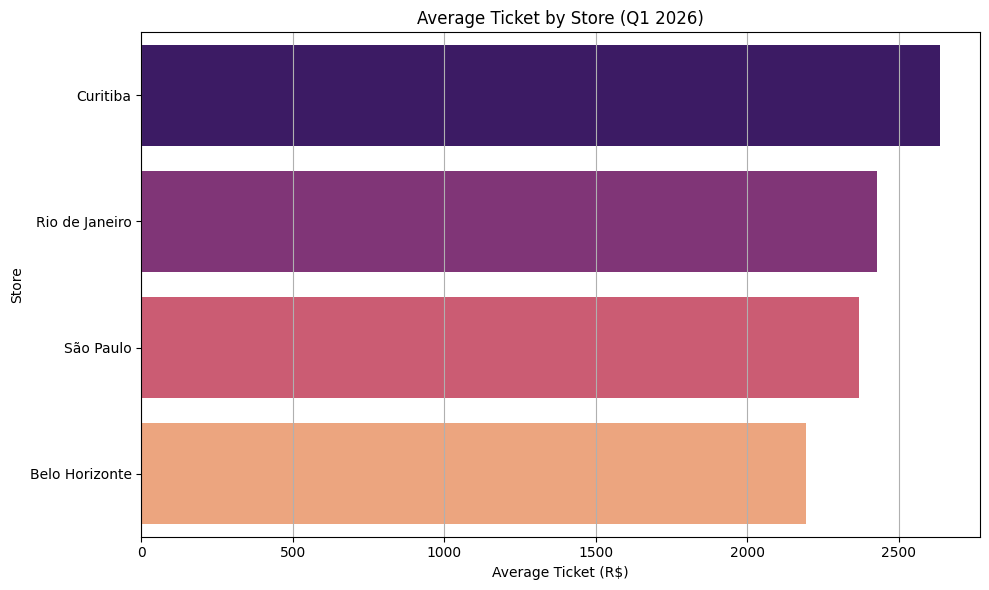

In [33]:
# Calculate the Average Ticket per transaction
df_quarter01_2026['Ticket Médio'] = df_quarter01_2026['Faturamento Bruto'] / df_quarter01_2026['Qtd']

# Calculate the total Average Ticket
ticket_medio_total = df_quarter01_2026['Ticket Médio'].mean()
print(f"Overall Average Ticket: R$ {ticket_medio_total:.2f}")

# Group by store and calculate the Average Ticket
ticket_medio_por_loja = df_quarter01_2026.groupby('Loja')['Ticket Médio'].mean().reset_index().sort_values(by='Ticket Médio', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Ticket Médio', y='Loja', data=ticket_medio_por_loja, palette='magma')
plt.title('Average Ticket by Store (Q1 2026)')
plt.xlabel('Average Ticket (R$)')
plt.ylabel('Store')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Top Seller by Gross Revenue

This analysis identifies the product that generated the highest gross revenue in the quarter.

The top seller product by Gross Revenue is: Amplificador 50W with R$ 399229.00


/tmp/ipykernel_11996/516911522.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faturamento Bruto', y='Produto', data=top_10_produtos, palette='coolwarm')


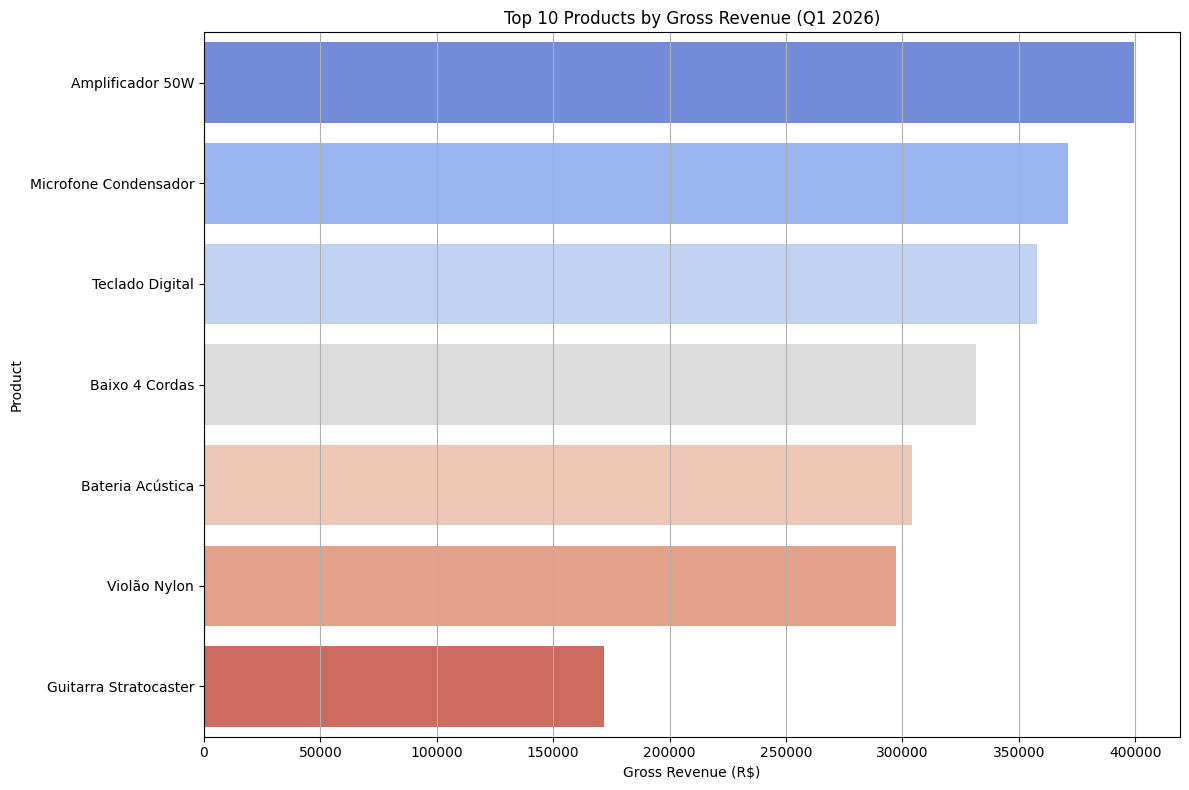

In [34]:
# Identify the product with the highest gross revenue
top_seller_produto = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().idxmax()
top_seller_valor = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().max()

print(f"The top seller product by Gross Revenue is: {top_seller_produto} with R$ {top_seller_valor:.2f}")

# Display the top 10 products by gross revenue
top_10_produtos = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(x='Faturamento Bruto', y='Produto', data=top_10_produtos, palette='coolwarm')
plt.title('Top 10 Products by Gross Revenue (Q1 2026)')
plt.xlabel('Gross Revenue (R$)')
plt.ylabel('Product')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Gross Revenue Ranking by Store

This ranking lists stores in descending order of gross revenue, highlighting the best-performing ones.

In [35]:
# The 'faturamento_por_loja' DataFrame has already been calculated and is sorted in 'Faturamento Bruto por Loja'
# Just display it with an explicit ranking

faturamento_por_loja_rank = faturamento_por_loja.copy()
faturamento_por_loja_rank['Rank'] = faturamento_por_loja_rank['Faturamento Bruto'].rank(ascending=False).astype(int)

display(faturamento_por_loja_rank.set_index('Rank'))

,Loja,Faturamento Bruto
Rank,,
1,São Paulo,685366
2,Curitiba,572846
3,Rio de Janeiro,566308
4,Belo Horizonte,408578


### Ticket Médio

Esta seção calcula e exibe o ticket médio por transação e por loja, fornecendo insights sobre o valor médio das vendas.

Ticket Médio Geral: R$ 2415.96


/tmp/ipykernel_11996/4258911065.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticket Médio', y='Loja', data=ticket_medio_por_loja, palette='magma')


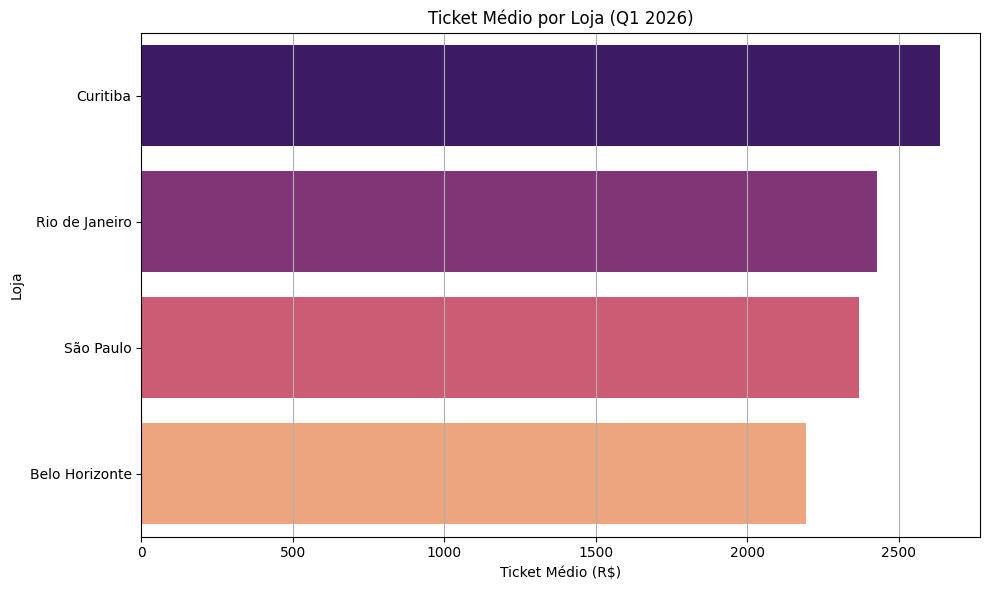

In [30]:
# Calcular o Ticket Médio por transação
df_quarter01_2026['Ticket Médio'] = df_quarter01_2026['Faturamento Bruto'] / df_quarter01_2026['Qtd']

# Calcular o Ticket Médio total
ticket_medio_total = df_quarter01_2026['Ticket Médio'].mean()
print(f"Ticket Médio Geral: R$ {ticket_medio_total:.2f}")

# Agrupar por loja e calcular o Ticket Médio
ticket_medio_por_loja = df_quarter01_2026.groupby('Loja')['Ticket Médio'].mean().reset_index().sort_values(by='Ticket Médio', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Ticket Médio', y='Loja', data=ticket_medio_por_loja, palette='magma')
plt.title('Ticket Médio por Loja (Q1 2026)')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Loja')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Top Seller por Faturamento Bruto

Esta análise identifica o produto que gerou o maior faturamento bruto no trimestre.

O produto top seller por Faturamento Bruto é: Amplificador 50W com R$ 399229.00


/tmp/ipykernel_11996/999831001.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faturamento Bruto', y='Produto', data=top_10_produtos, palette='coolwarm')


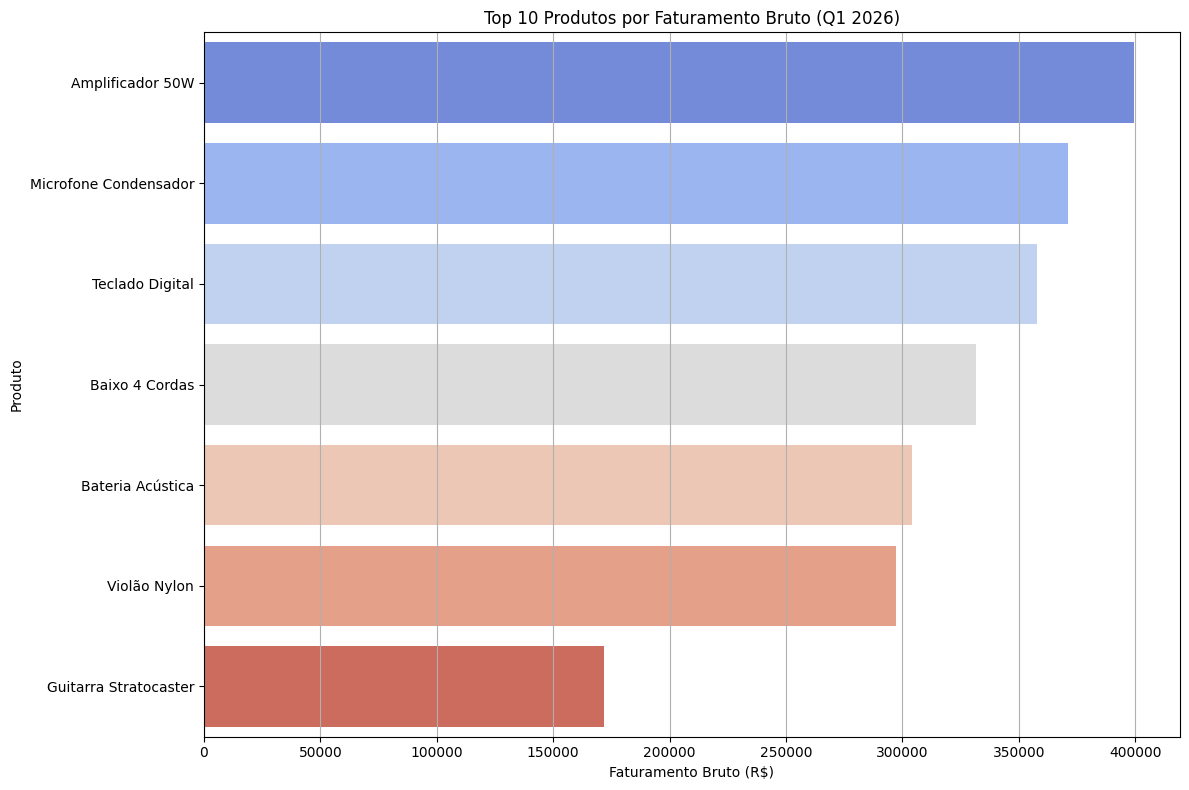

In [31]:
# Identificar o produto com maior faturamento bruto
top_seller_produto = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().idxmax()
top_seller_valor = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().max()

print(f"O produto top seller por Faturamento Bruto é: {top_seller_produto} com R$ {top_seller_valor:.2f}")

# Exibir os top 10 produtos por faturamento bruto
top_10_produtos = df_quarter01_2026.groupby('Produto')['Faturamento Bruto'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(x='Faturamento Bruto', y='Produto', data=top_10_produtos, palette='coolwarm')
plt.title('Top 10 Produtos por Faturamento Bruto (Q1 2026)')
plt.xlabel('Faturamento Bruto (R$)')
plt.ylabel('Produto')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Ranking de Faturamento Bruto por Loja

Este ranking lista as lojas em ordem decrescente de faturamento bruto, destacando as de melhor desempenho.

In [32]:
# O DataFrame 'faturamento_por_loja' já foi calculado e está ordenado em 'Faturamento Bruto por Loja'
# Basta exibi-lo com um ranking explícito

faturamento_por_loja_rank = faturamento_por_loja.copy()
faturamento_por_loja_rank['Rank'] = faturamento_por_loja_rank['Faturamento Bruto'].rank(ascending=False).astype(int)

display(faturamento_por_loja_rank.set_index('Rank'))

,Loja,Faturamento Bruto
Rank,,
1,São Paulo,685366
2,Curitiba,572846
3,Rio de Janeiro,566308
4,Belo Horizonte,408578
